<a href="https://colab.research.google.com/github/louis-uwie/CSCI161-SocialComputing/blob/main/Binwag-FinalProject/CSCI161.03%20-%20BINWAG%2C%20Louis%20III%20-%20Data%20Analysis%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CSCI 161.03 - Introduction to Social Computing**

**Author:** BINWAG, Louis III G. (`github/louis-uwie`)

# **I. Introduction**

As part of the major requirement for **CSCI 161.03 - Introduction to Social Computing**, the author wants to dabble into social dynamics in subreddit discussions that concern the Philippines.

In `r/truePhilippines`, users tend to interact about on-going controversial issues in the Philippines. This ranges from the most recent `Nepo Babies` to rather old but still very relevant and recurring, `Agricultural Prices`.

**What I want to find out are:**

1. What are the **recurring themes** and topics in these discussions?
2. What **dominant emotions** or sentiments emerge in online conversations about the Philippines?
3. **[NOT YET FINAL, STILL THINKING ON SUBJECT SCOPE]** How do users interact with one another *(e.g., patterns of agreement, disagreement, or polarization)* when engaging in these topics?

# **II. About the Dataset**

 Please note that there is a great chance of including other social media platforms as well due to rate-limits of Reddit API Scraping.

Currently, there is `248 Rows`, and `8 Columns`.


| Column           | Definition                                      | Sample                                                              |
| ---------------- | ----------------------------------------------- | ------------------------------------------------------------------- |
| `post_title`     | Title of the Reddit post                        | *"Why is Python so popular in data science?"*                       |
| `post_url`       | Direct link to the Reddit post                  | `https://www.reddit.com/r/datascience/comments/abc123/...`          |
| `post_body`      | Main body text of the Reddit post (if provided) | *"I’ve noticed a lot of job postings require Python experience..."* |
| `post_author`    | Username of the Reddit post’s author            | `u/data_guru`                                                       |
| `post_score`     | Upvotes minus downvotes for the post            | `1542`                                                              |
| `comment`        | Text of the Reddit comment                      | *"Python has great libraries like pandas and scikit-learn."*        |
| `comment_author` | Username of the Reddit comment’s author         | `u/ml_enthusiast`                                                   |
| `comment_score`  | Upvotes minus downvotes for the comment         | `237`                                                               |



# **III. Data Collection**

Data collection will primarily utilize Reddit's PRAW (API) for datascraping. Connecting to Google drive for ease of use since the author will be using google collab for a more streamline and 'smoother' project.


In [67]:
!pip install praw

In [68]:
# from dotenv import load_dotenv
# import os

# load_dotenv("/content/drive/CSCI 161/Project/redditdatascrape.env", override=True)

# CLIENT_ID = os.getenv("CLIENT_ID")
# CLIENT_SECRET = os.getenv("CLIENT_SECRET")

# print("CLIENT_ID:", CLIENT_ID)
# print("CLIENT_SECRET:", CLIENT_SECRET)


In [69]:
import pandas as pd
import numpy as np
import nltk

import praw

import pandas as pd
from google.colab import drive
import datetime

import os

In [70]:
reddit = praw.Reddit(
    client_id="390Mv4deA5sjduaY4-n2TA",
    client_secret="-lvWJJC94wvX8-7DLNrp0wgaa70EOA",
    user_agent="script:reddit_scraper:v1.0"
)

print("Read-only mode:", reddit.read_only)


Read-only mode: True


In [71]:
# Mount Google Drive
drive.mount('/content/drive')

subreddit = reddit.subreddit("Philippines")

posts_data = []

# Fetch more posts (adjust as needed)
for post in subreddit.hot(limit=500):
    body = post.selftext if post.selftext else "[No text - maybe image/link post]"

    posts_data.append({
        "post_title": post.title,
        "post_url": "https://reddit.com" + post.permalink,
        "comment": None,
        "comment_author": None,
        "comment_score": None,
        "post_body": body,
        "post_score": post.score,
        "post_author": post.author.name if post.author else "[deleted]",
        "created_utc": pd.to_datetime(post.created_utc, unit="s")  # <-- post timestamp
    })

    # Fetch comments
    post.comments.replace_more(limit=0)
    for comment in post.comments.list():
        posts_data.append({
            "post_title": post.title,
            "post_url": "https://reddit.com" + post.permalink,
            "comment": comment.body,
            "comment_author": comment.author.name if comment.author else "[deleted]",
            "comment_score": comment.score,
            "post_body": None,
            "post_score": None,
            "post_author": None,
            "created_utc": pd.to_datetime(comment.created_utc, unit="s")  # <-- comment timestamp
        })

# Save to Google Drive
df = pd.DataFrame(posts_data)

output_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"
df.to_csv(output_path, index=False)

print(f"Saved {len(df)} rows to {output_path}")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Saved 23243 rows to /content/drive/MyDrive/reddit_truephilippines1000.csv


In [72]:
# from google.colab import drive
# import pandas as pd
# import time

# # Mount Google Drive
# drive.mount('/content/drive')

# subreddit = reddit.subreddit("truePhilippines")

# posts_data = []
# post_count = 0
# max_posts = 1000
# requests_made = 0
# start_time = time.time()

# for post in subreddit.hot(limit=None):
#     if post_count >= max_posts:
#         break

#     requests_made += 1
#     if requests_made >= 10:
#         elapsed = time.time() - start_time
#         if elapsed < 60:
#             sleep_time = 60 - elapsed
#             print(f"Sleeping {sleep_time:.1f} seconds to respect rate limits...")
#             time.sleep(sleep_time)

#         requests_made = 0
#         start_time = time.time()


#     body = post.selftext if post.selftext else "[No text - maybe image/link post]"
#     posts_data.append({
#         "post_title": post.title,
#         "post_url": "https://reddit.com" + post.permalink,
#         "comment": None,
#         "comment_author": None,
#         "comment_score": None,
#         "post_body": body,
#         "post_score": post.score,
#         "post_author": post.author.name if post.author else "[deleted]",
#         "created_utc": pd.to_datetime(post.created_utc, unit="s")
#     })
#     post_count += 1

#     post.comments.replace_more(limit=0)
#     for comment in post.comments.list():
#         posts_data.append({
#             "post_title": post.title,
#             "post_url": "https://reddit.com" + post.permalink,
#             "comment": comment.body,
#             "comment_author": comment.author.name if comment.author else "[deleted]",
#             "comment_score": comment.score,
#             "post_body": None,
#             "post_score": None,
#             "post_author": None,
#             "created_utc": pd.to_datetime(comment.created_utc, unit="s")
#         })

# print(f"Collected {post_count} posts (with comments included).")

# df = pd.DataFrame(posts_data)
# output_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"
# df.to_csv(output_path, index=False)

# print(f"Saved {len(df)} rows to {output_path}")


# **IV. Exploratory Data Analysis**

Basic EDA to understand the data better.


In [73]:
for f in os.listdir("/content/drive/MyDrive"):
    if "reddit" in f:
        print(f)

reddit_truephilippinesAAA.csv
reddit_truephilippines1000.csv


In [74]:
# Path to the file you saved earlier
file_path = "/content/drive/MyDrive/reddit_truephilippines1000.csv"

# Load CSV
reddit_raw = pd.read_csv(file_path)

In [75]:
print("Shape:", reddit_raw.shape)   # rows x columns
print("\nColumns:", reddit_raw.columns.tolist())
print("\nPreview:")
reddit_raw.head()

Shape: (23243, 9)

Columns: ['post_title', 'post_url', 'comment', 'comment_author', 'comment_score', 'post_body', 'post_score', 'post_author', 'created_utc']

Preview:


,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
0,"[HUB] Weekly Help Thread, Random Discussion, E...",https://reddit.com/r/Philippines/comments/fztq...,NaN,NaN,NaN,\nWelcome to the r/Philippines hub thread! Whe...,368.0,the_yaya,2020-04-12 09:28:38
1,📢 Quick Reminder on Low Effort Posts & Crosspo...,https://reddit.com/r/Philippines/comments/1n2v...,NaN,NaN,NaN,"In the past few days, we’ve noticed a surge of...",38.0,dadidutdut,2025-08-29 02:05:55
2,📢 Quick Reminder on Low Effort Posts & Crosspo...,https://reddit.com/r/Philippines/comments/1n2v...,Latak ng FB tumatagas sa r/ph.,Prestigious-Guava220,13.0,NaN,NaN,NaN,2025-08-29 03:09:43
3,📢 Quick Reminder on Low Effort Posts & Crosspo...,https://reddit.com/r/Philippines/comments/1n2v...,"About time, ginagawa na nilang FB tong sub dah...",beklog,14.0,NaN,NaN,NaN,2025-08-29 02:16:08
4,📢 Quick Reminder on Low Effort Posts & Crosspo...,https://reddit.com/r/Philippines/comments/1n2v...,May nagtatrabaho ba sa jollibee dito? Are they...,sikarl,0.0,NaN,NaN,NaN,2025-09-02 15:19:42


In [76]:
reddit_raw.tail()

,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
23238,another political dynasty: tagaytay represent ...,https://reddit.com/r/Philippines/comments/1n4u...,Wow ginawang family business,yoo_rahae,2.0,NaN,NaN,NaN,2025-08-31 20:34:41
23239,another political dynasty: tagaytay represent ...,https://reddit.com/r/Philippines/comments/1n4u...,Kaya bulok yang tagaytay eh.,koniks0001,2.0,NaN,NaN,NaN,2025-09-01 00:12:32
23240,another political dynasty: tagaytay represent ...,https://reddit.com/r/Philippines/comments/1n4u...,![gif](giphy|SqmkZ5IdwzTP2)\n\nTagaytay voters...,cakenmistakes,1.0,NaN,NaN,NaN,2025-09-04 03:44:53
23241,another political dynasty: tagaytay represent ...,https://reddit.com/r/Philippines/comments/1n4u...,HAHAHA Kaloka,caiigat-cayo,1.0,NaN,NaN,NaN,2025-09-01 07:36:11
23242,Alon ng Kabayanihan Behind the Scenes | Carlo ...,https://reddit.com/r/Philippines/comments/1n5a...,NaN,NaN,NaN,[No text - maybe image/link post],6.0,b_zar,2025-09-01 00:09:08


## **Word Cloud for Visualization**

In [ ]:

# Define stopwords (optional: add more custom ones)
stopwords = set(STOPWORDS)
stopwords.update([
    # Pronouns (personal, demonstrative, interrogative)
    "ako", "ikaw", "siya", "kami", "tayo", "kayo", "sila",
    "niya", "nila", "natin", "namin", "inyo", "atin",
    "ito", "iyan", "iyon", "nito", "niyan", "noon",
    "dito", "diyan", "doon", "dito'y", "diyan", "roon",
    "sino", "ano", "alin", "kanino", "kaniya", "kanila",
    "kanya", "amin", "saan", "kailan", "paano", "bakit",

    # Articles & markers
    "ang", "ng", "mga", "si", "ni", "kay", "kina", "sa",
    "yung", "yong", "itong", "ganyan", "ganito", "ganun",

    # Particles (focus, aspect, discourse markers)
    "ba", "pa", "na", "naman", "rin", "din", "man", "daw",
    "raw", "pala", "kasi", "nga", "dapat", "sana", "muna",
    "lang", "talaga", "yata", "siguro", "parang", "kumbaga",
    "bale", "naka", "naka-", "nag", "nag-", "mag", "mag-",
    "pag", "pa-", "paki", "paki-", "pinaka", "pinaka-",

    # Conjunctions
    "at", "o", "kung", "kapag", "pag", "habang", "bago",
    "matapos", "pagkatapos", "subalit", "ngunit", "pero",
    "kahit", "samantalang", "kung kaya", "kaya", "upang",
    "para", "dahil", "sapagkat", "kung gayon", "kundi",
    "gayundin", "gayunman", "maski", "palibhasa", "kaya't",

    # Common verbs (light/auxiliary forms)
    "may", "wala", "meron", "nandiyan", "naroon", "nandito",
    "pwede", "maari", "gusto", "ayaw", "kaya", "ibig", "nais",
    "tama", "mali", "dapat", "maari", "puwede", "hindi",
    "oo", "opo", "huwag", "wag",

    # Numbers (often stop words in NLP)
    "isa", "dalawa", "tatlo", "apat", "lima", "anim", "pito",
    "walo", "siyam", "sampu", "labing", "dalawampu", "tatlumpu",
    "apatnapu", "limampu", "animnapu", "pitumpu", "walumpu",
    "siyamnapu", "daan", "libo", "milyon",

    # Time expressions
    "ngayon", "kahapon", "bukas", "mamaya", "kanina", "noon",
    "palagi", "lagi", "minsan", "madalas", "bihira", "oras",
    "sandali", "panahon", "taon", "buwan", "linggo", "araw",

    # Location/direction words
    "dito", "diyan", "doon", "roon", "narito", "nariyan",
    "nandoon", "nandiyan", "nandito", "malapit", "malayo",
    "ibabaw", "ilalim", "harap", "likod", "kanan", "kaliwa",

    # Fillers / discourse
    "ano", "ano'ng", "anong", "eh", "ah", "uh", "uy", "hala",
    "naku", "hala", "hoy", "aba", "hala", "tsk", "ay", "ho",
    "po", "eh", "ala", "hala", "yow", "grabe",

    # Frequent content words (too common, low semantic value)
    "tao", "bata", "gabi", "umaga", "tanghali", "hapon",
    "trabaho", "bahay", "lugar", "bagay", "araw", "panahon",
    "oras", "daan", "gamit", "pera", "anak", "magulang",
    "kaibigan", "pangalan",

    # English loanwords / hybrid frequent terms
    "okay", "ok", "opo", "oo", "sorry", "thank", "thanks",
    "pls", "please", "wala", "meron", "ayos", "sige",

    # Redundant forms (hyphenated and root)
    "kaya", "kaya't", "gayunman", "gayundin", "samakatwid",
    "dahil", "dahilan", "sapagkat", "palibhasa",

    # Extra fillers
    "ano", "nga", "na", "eh", "kaya", "naku", "hala", "ay",
    "aba", "hoy", "daw", "raw", "lang", "po", "ho", "pa",
    "muna", "talaga", "yata", "siguro", "pala", "naman",
    "rin", "din", "man", "kasi", "nga", "dapat", "sana",
    "parang", "kumbaga", "bale", "ano", "ano'ng", "ganun",
    "ganito", "ganyan", "ganoon",

    # Morphological roots (to catch variants)
    "mag", "nag", "um", "in", "an", "han", "ka", "ma", "pa",
    "pag", "pinaka", "ika", "ika-", "tag", "taga", "pang",
    "pinag", "ipinag", "ika'y", "ako'y", "ikaw'y", "siya'y",

    # Reduplication forms (very common)
    "samasama", "ibatiba", "kungkung", "paraparang", "sandaling",
    "minsanminsan", "lagi-lagi", "paminsan", "paminsanminsan",

    # Catch-all common verbs/nouns with low info value
    "kumain", "uminom", "magpunta", "pumunta", "dumating",
    "umalis", "tumakbo", "lumakad", "maglakad", "sumakay",
    "mag-aral", "magtrabaho", "maglaro", "magpahinga",
    "magbasa", "sumulat", "magusap", "magsalita", "magsabi",
    "magbigay", "magkaroon", "gumawa", "magawa",

    # More conjunction/discourse
    "pero", "ngunit", "subalit", "gayundin", "gayunpaman",
    "bagaman", "kahit", "maski", "palibhasa", "kung gayon",
    "sa wakas", "sa huli", "bilang", "dahil dito", "samakatwid"
])  # added based on domain knowledge.


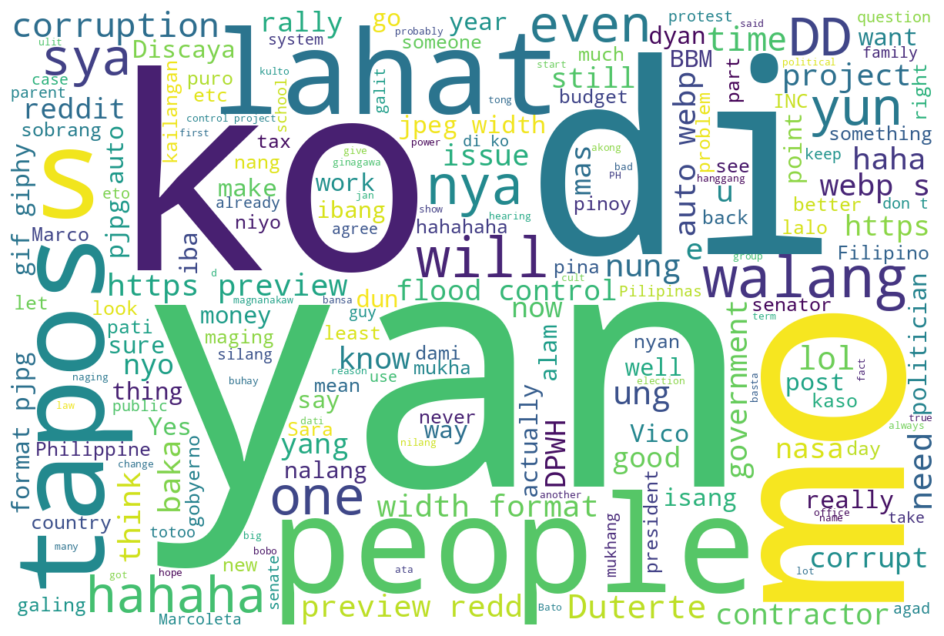

In [91]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['comment'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


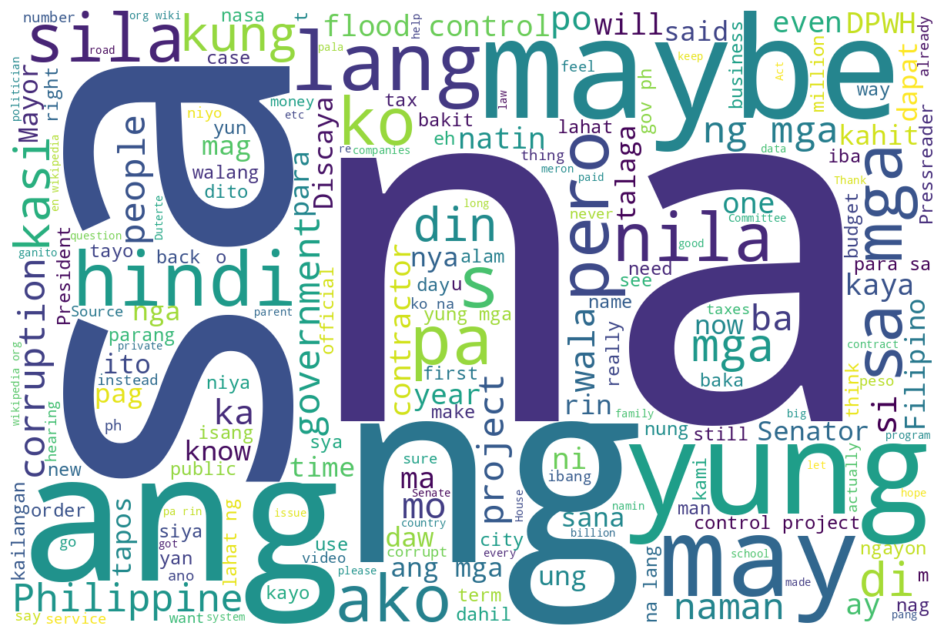

In [92]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['post_body'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Define stopwords (optional: add more custom ones)
stopwords = set(STOPWORDS)
stopwords.update(["https", "http", "www", "com", "link", "image", "text", "link", "post"])  # extend stopwords

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


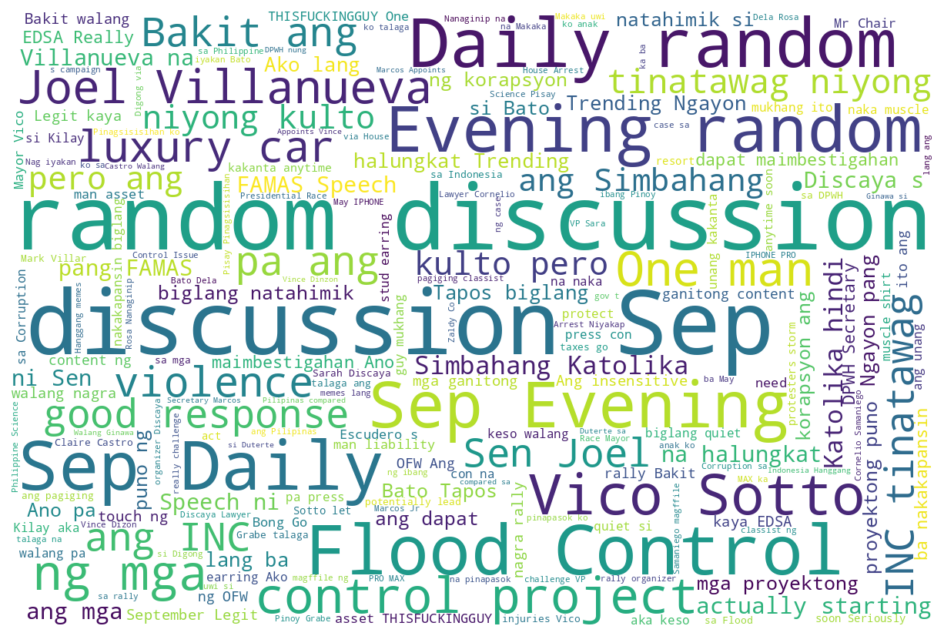

In [93]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine the text from 'comment' and 'post_body'
text_data = reddit_raw['post_title'].fillna('')

# Join all rows into one string
all_text = " ".join(text_data.astype(str))

# Define stopwords (optional: add more custom ones)
stopwords = set(STOPWORDS)
stopwords.update(["https", "http", "www", "com", "link", "image", "text", "link", "post"])  # extend stopwords

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=True
).generate(all_text)

# Plot the WordCloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


## **Term Frequency-based Analysis**

In [94]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Define stopwords
stopwords = set(STOPWORDS)
stopwords.update(["https", "http", "www", "com", "link", "image", "text", "post"])

# Convert set to list for CountVectorizer
stopwords_list = list(stopwords)

# Vectorize post_body (fill NaN first)
vectorizer = CountVectorizer(stop_words=stopwords_list, max_features=2000)
matrix = vectorizer.fit_transform(reddit_raw["post_body"].fillna(""))


matrix.toarray()



/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [95]:
vectorizer.get_feature_names_out()

array(['00', '000', '05', ..., 'yun', 'yung', 'zero'], dtype=object)

In [96]:
total_per_ngram = matrix.sum(axis=0)
frequency = [(w, total_per_ngram[0, i]) for w, i in vectorizer.vocabulary_.items()]
frequency


[('welcome', np.int64(4)),
 ('philippines', np.int64(64)),
 ('thread', np.int64(5)),
 ('trying', np.int64(9)),
 ('go', np.int64(31)),
 ('daily', np.int64(15)),
 ('discussion', np.int64(5)),
 ('06', np.int64(4)),
 ('2025', np.int64(35)),
 ('reddit', np.int64(13)),
 ('comments', np.int64(11)),
 ('help', np.int64(20)),
 ('june', np.int64(8)),
 ('past', np.int64(14)),
 ('days', np.int64(12)),
 ('ve', np.int64(26)),
 ('effort', np.int64(4)),
 ('posts', np.int64(13)),
 ('often', np.int64(9)),
 ('personal', np.int64(5)),
 ('thoughts', np.int64(7)),
 ('without', np.int64(9)),
 ('enough', np.int64(7)),
 ('context', np.int64(7)),
 ('well', np.int64(14)),
 ('claims', np.int64(5)),
 ('sources', np.int64(11)),
 ('keep', np.int64(15)),
 ('sub', np.int64(3)),
 ('clean', np.int64(3)),
 ('ll', np.int64(12)),
 ('start', np.int64(5)),
 ('make', np.int64(18)),
 ('similar', np.int64(7)),
 ('feel', np.int64(15)),
 ('free', np.int64(20)),
 ('please', np.int64(20)),
 ('use', np.int64(35)),
 ('instead', np.int

In [97]:
frequency = pd.DataFrame(frequency, columns=['term', 'frequency'])
frequency

,term,frequency
0,welcome,4
1,philippines,64
2,thread,5
3,trying,9
4,go,31
...,...,...
1995,payments,3
1996,movie,3
1997,reelection,3
1998,nazal,5


In [98]:
frequency = frequency.sort_values(by='frequency', ascending=False).reset_index(drop=True)
frequency

,term,frequency
0,na,745
1,sa,677
2,ng,533
3,ang,389
4,mga,369
...,...,...
1995,reelection,3
1996,bod,3
1997,sub,3
1998,clean,3


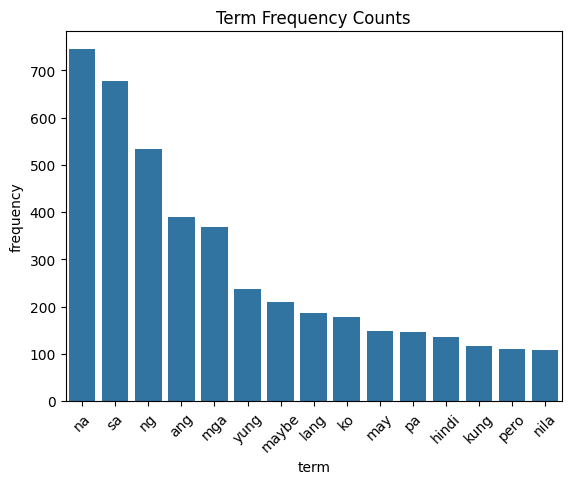

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

top15 = frequency.sort_values(by="frequency", ascending=False).head(15)

title = "Term Frequency Counts"
ax = sns.barplot(data=top15, x="term", y="frequency")

if title:
    ax.set_title(title)

plt.xticks(rotation=45)
plt.show()
plt.close()

# **V. Data Preprocessing**

The author aims to **clean** the dataset after understanding the data previously in the EDA section.

During this stage, various data manipulation techniques are performed such as but not limited to:
- Removing NaN values
- Removing deleted comments / authors
- Removing 'non-word' data *(i.e., "asdnasndjasdnasndjasndjasn")*

These are performed to hopefully clean the data for better analysis through social computing methods

***This section is still work in progress because I still lack data, still at `248 rows of data.` Currently planning to get at least a thousand by combining online threads from different platforms.***

# **VI. Social Computing Methods**

**[ WORK IN PROGRESS ]**

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Morbi scelerisque nulla id nulla dapibus, ac suscipit neque convallis. Nullam id suscipit purus. Aenean suscipit dolor in hendrerit varius. Mauris lacinia tincidunt condimentum. Mauris vel ligula quis odio imperdiet iaculis vitae a velit.

# **VII. Results and Conclusion**

**[ WORK IN PROGRESS ]**

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Morbi scelerisque nulla id nulla dapibus, ac suscipit neque convallis. Nullam id suscipit purus. Aenean suscipit dolor in hendrerit varius. Mauris lacinia tincidunt condimentum. Mauris vel ligula quis odio imperdiet iaculis vitae a velit.

# **VIII. References**

**[ WORK IN PROGRESS ]**

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Morbi scelerisque nulla id nulla dapibus, ac suscipit neque convallis. Nullam id suscipit purus. Aenean suscipit dolor in hendrerit varius. Mauris lacinia tincidunt condimentum. Mauris vel ligula quis odio imperdiet iaculis vitae a velit.